
📚 **参考:** [[Scaling book 关于 Transformer 的章节]](https://jax-ml.github.io/scaling-book/transformers/)

📚 **参考:** [[Scaling book 关于推理的章节]](https://jax-ml.github.io/scaling-book/inference/)

**符号定义 (Notations)**

| 符号 | 含义 (Meaning) | 备注 (Remarks) |
| :--- | :--- | :--- |
| **$B$** | Batch Size (批次大小) | 一次推理或训练中处理的序列数量 |
| **$S$** | Sequence Length (Input) (输入序列长度) | 提示词 (Prompt) 的长度 |
| **$T$** | Sequence Length (Generated) (生成序列长度) | 生成的 Token 数量 (在 Prefill 阶段 $T=S$, 在 Generation 阶段 $T=1$) |
| **$D$** | Model Dimension (模型维度) | 隐藏层向量的维度 (Hidden Size) |
| **$F$** | Feedforward Dimension (前馈层维度) | MLP 层中间放大的维度 (通常 $F \approx 4D$) |
| **$N$** | Number of Query Heads (Query 头数) | 注意力机制中 Query 的头数 |
| **$K$** | Number of Key/Value Heads (KV 头数) | 注意力机制中 Key/Value 的头数 (GQA 中 $K < N$) |
| **$H$** | Head Dimension (注意力头维度) | 每个注意力头的维度 (通常 $D = N \times H$) |
| **$L$** | Number of Layers (层数) | Transformer 的层数 |
| **$V$** | Vocabulary Size (词表大小) | 词表中 Token 的总数量 |
| **$c$** | Constant (常数) | 用于极限计算的辅助常数 |
| **$X$** | Input Matrix (输入矩阵) | 形状通常为 $[B, T, D]$ |
| **$W$** | Weight Matrix (权重矩阵) | 包括 $W_{up}, W_{gate}, W_{down}, W_Q, W_K, W_V, W_O$ 等 |
| **$Q, K, V$** | Query, Key, Value Matrices | 注意力机制中的三个核心矩阵 |

## 1. 推理概览 (The Inference Landscape)

在这一章，我们将深入探讨 LLM 的推理。推理并不仅仅是模型训练完成后的“最后一步”，它是大模型产生实际价值的核心环节。

### 1.1 推理无处不在

大模型的推理应用场景比我们想象的要广泛得多，主要包括以下几个方面：

* **实际应用 (Real-world Deployment)**：这是最直观的场景，包括聊天机器人（Chatbots）、代码自动补全（Code Completion）以及大规模的数据处理任务。
* **模型评估 (Model Evaluation)**：在评估模型能力（例如指令遵循 Instruction Following）时，我们需要通过推理生成结果来进行打分。
* **测试时计算 (Test-time compute)**：这是最近的一个研究热点（如 OpenAI o1 系列），即通过在推理阶段让模型进行更多的“思考”（Chain of Thought），来换取更强的性能。
* **强化学习训练 (RL Training)**：在 RLHF 或 RLAIF 流程中，我们需要先生成大量的样本（Rollouts），然后对其进行打分和优化，这也是一个推理密集型的过程。

### 1.2 为什么效率至关重要？

为什么我们要花这么大精力去优化推理系统？

一个核心的经济学逻辑是：**训练是一次性的固定成本，而推理是会重复无数次的边际成本。** 当模型被广泛应用时，推理成本将占据主导地位。

看看下面这些惊人的数据，你就能感受到推理规模的庞大：

**OpenAI 的 Token 处理量**

![](../images/openai-100b-tokens.png)

> 🔗 [Sam Altman 的推文](https://x.com/sama/status/1756089361609981993)

**Cursor 的代码生成量**

![](../images/cursor-1b-lines.png)

> 🔗 [Aman Sanger 的推文](https://x.com/amanrsanger/status/1916968123535880684)

### 1.3 关键性能指标 (Metrics)

在优化推理系统之前，我们需要定义“什么是快”。通常我们关注以下三个核心指标：

1.  **首字生成时间 (TTFT, Time To First Token)**：
    * 用户在生成开始前需要等待多久？
    * *重要性*：对交互式应用（如 ChatGPT）的用户体验至关重要。
2.  **延迟 (Latency, seconds/token)**：
    * 用户看到后续 token 蹦出来的速度有多快？
    * *重要性*：直接影响用户的阅读流畅感。
3.  **吞吐量 (Throughput, tokens/second)**：
    * 系统单位时间内能处理多少 token？
    * *重要性*：对批量处理应用（Batch Processing）非常有用。



### 1.4 效率的关键考量因素

理解了指标后，我们需要明白为什么推理优化如此困难。这本质上是由 Transformer 的架构特性决定的：

* **训练 (监督式)**：这是一个**并行**过程。因为通过 Mask 机制，我们可以同时看到所有的 token，这意味着我们可以在序列维度上利用矩阵乘法进行大规模并行化。
* **推理 (自回归)**：这是一个**串行**过程。生成第 $t$ 个 token 必须依赖于第 $t-1$ 个 token。这种无法并行化的特性，使得计算资源（GPU）极难被充分利用，受到内存带宽的限制（Memory Bound）。

### 1.5 推理生态圈

目前，推理服务是一个巨大的市场，主要参与者分为两类：

#### 商业模型供应商
这些公司提供闭源模型的 API 服务，对任何拥有产品或平台的人来说都是大事：
* **OpenAI, Anthropic, Google** 等。

#### 开放权重模型供应商
这些平台专注于托管和加速开源模型（如 Llama 3, Mixtral）：
* **Together AI, Fireworks AI, DeepInfra** 等。

### 1.6 开源推理引擎 (Open Source Packages)

作为研究者或开发者，我们通常会使用以下高性能的开源库来部署模型：

* **vLLM (Berkeley)**
    * 目前最流行的推理框架之一，以 PagedAttention 技术闻名。
    * 🔗 [[演讲]](https://www.youtube.com/watch?v=8BaEwoTk8XI)
* **TensorRT-LLM (NVIDIA)**
    * NVIDIA 官方推出的极致优化库，针对 GPU 硬件进行了深度定制。
    * 🔗 [Link](https://nvidia.github.io/TensorRT-LLM/overview.html)
    * 🔗 [文章](https://nvidia.github.io/TensorRT-LLM/overview.html)
* **TGI (Text Generation Inference by Hugging Face)**
    * Hugging Face 官方的生产级推理容器。
    * 🔗 [Link](https://huggingface.co/docs/text-generation-inference/en/index)
    * 🔗 [文章](https://huggingface.co/docs/text-generation-inference/en/index)

## 2. Transformer 架构回顾 (Review Transformer)

在我们深入推理优化之前，先快速回顾一下 Transformer 的基本形态。这部分内容参考了 Google DeepMind 的 Scaling Book。

* 📚 **推荐阅读**: [[Scaling book 关于 Transformer 的章节]](https://jax-ml.github.io/scaling-book/transformers/)

![Transformer Architecture](https://jax-ml.github.io/scaling-book/assets/img/transformer-diagram.png)

### 2.1 符号定义与计算量

为了后续分析方便，我们统一一下符号（遵循常见的 Scaling Law 惯例）：

* **$D$**: 模型隐藏层维度 (Model dimension)
* **$F$**: MLP 层的中间维度 (通常 $F = 4D$)
* **$H$**: Attention 头数 (Heads)
* **$N$**: 层数 (Layers)
* **$T$**: 当前这次计算需要处理的/生成的序列长度 (Sequence length)
* **$S$**: 存储的历史序列长度 (Sequence length)

一个粗略的估算公式是，Transformer 前向传播的计算量 (FLOPs) 大约为：

$$C \approx 6 \cdot B \cdot T \cdot P$$

其中 $B$ 是 Batch Size，$T$ 是序列长度，$P$ 是参数量。虽然这个公式忽略了一些非线性操作和 Attention 的 $O(T^2)$ 项，但对于大模型来说，它极其准确地描述了矩阵乘法（MatMul）的主导地位。

## 3. 算术强度 (Arithmetic Intensity)

当我们谈论“快”的时候，硬件层面主要受限于两个因素：**计算能力 (Compute)** 和 **内存带宽 (Memory Bandwidth)**。

### 3.1 矩阵乘法

让我们来算一笔账。设定标准矩阵乘法 $Y = X \cdot W$，其中：
* $X$: $(B, D)$ —— 输入 Activation ($B$ 是 Batch Size)
* $W$: $(D, F)$ —— 权重 Weight
* $Y$: $(B, F)$ —— 输出 Output
* **数据类型**：假设使用 BF16/FP16，每个元素占用 **2 bytes**。

**1. 内存传输量 (Memory Traffic)**
我们需要从 HBM (显存) 读取输入 $X$ 和权重 $W$，计算完成后将结果 $Y$ 写回。
$$\text{Bytes} = \underbrace{2BD}_{\text{Read } X} + \underbrace{2DF}_{\text{Read } W} + \underbrace{2BF}_{\text{Write } Y}$$

**2. 计算量 (Compute)**
矩阵乘法中，生成 $Y$ 的每一个元素需要 $D$ 次乘法和 $D$ 次加法，共 $2D$ 次浮点运算。输出矩阵共有 $B \times F$ 个元素。
$$\text{FLOPs} = 2 \cdot B \cdot D \cdot F$$

**3. 算术强度 (Arithmetic Intensity)**
即每传输 1 Byte 数据能进行多少次计算（越高越好）：
$$\text{Intensity} = \frac{\text{FLOPs}}{\text{Bytes}} = \frac{2BDF}{2BD + 2DF + 2BF} = \frac{BDF}{BD + DF + BF}$$

**4. 极限分析**
在 Transformer 中，$D$ (隐藏层维度) 和 $F$ (MLP 维度) 通常非常大（数千到数万），远大于 $B$。
如果我们假设 $D, F \gg B$（即分母中 $DF$ 项占主导地位），公式可以简化为：
$$\text{Intensity} \approx \frac{BDF}{DF} = B$$

**结论**：在模型维度足够大的情况下，矩阵乘法的算术强度上限约等于 **Batch Size ($B$)**。


 Batch |   Time(ms) |   TFLOPS
--------------------------------
     1 |      0.056 |     1.60
     2 |      0.054 |     3.34
     4 |      0.054 |     6.64
     8 |      0.055 |    13.19
    16 |      0.056 |    25.94
    32 |      0.056 |    51.31
    64 |      0.057 |   100.62
   128 |      0.060 |   191.71
   256 |      0.062 |   371.21
   512 |      0.111 |   415.62
  1024 |      0.205 |   449.81
  2048 |      0.385 |   479.38


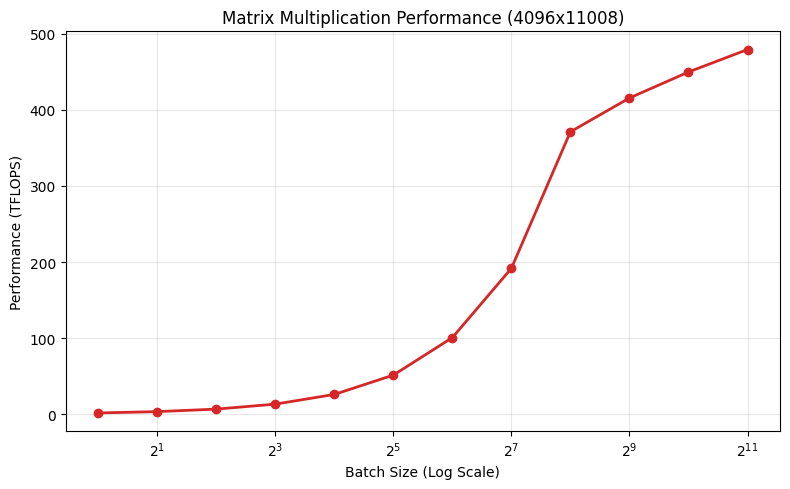

In [5]:

import torch
import matplotlib.pyplot as plt

def benchmark_batch_impact(D=4096, F=11008):
    """
    实测不同 Batch Size 下的矩阵乘法性能 (TFLOPS)
    """
    if not torch.cuda.is_available():
        return print("⚠️ Need CUDA GPU for this benchmark.")

    device = torch.device("cuda")
    W = torch.randn(D, F, device=device, dtype=torch.float16)
    
    # 生成 Batch 序列: 1, 2, 4, ..., 2048
    batch_sizes = [2**i for i in range(12)]
    tflops_list = []

    print(f"{'Batch':>6} | {'Time(ms)':>10} | {'TFLOPS':>8}")
    print("-" * 32)
    
    for B in batch_sizes:
        X = torch.randn(B, D, device=device, dtype=torch.float16)
        
        # Warmup
        torch.matmul(X, W); torch.cuda.synchronize()
        
        # Timing (GPU Event is more accurate than time.time)
        start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
        
        start.record()
        for _ in range(50): torch.matmul(X, W) # 运行多次取平均
        end.record()
        torch.cuda.synchronize()
        
        # Compute Stats
        avg_time = start.elapsed_time(end) / 50 / 1000 # ms -> seconds
        tflops = (2 * B * D * F) / avg_time / 1e12
        tflops_list.append(tflops)
        
        print(f"{B:6d} | {avg_time*1000:10.3f} | {tflops:8.2f}")

    # Visualization
    plt.figure(figsize=(8, 5))
    plt.plot(batch_sizes, tflops_list, 'o-', color='#d62728', lw=2)
    plt.xscale('log', base=2)
    plt.xlabel('Batch Size (Log Scale)'); plt.ylabel('Performance (TFLOPS)')
    plt.title(f'Matrix Multiplication Performance ({D}x{F})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 运行
benchmark_batch_impact()

### 3.2 硬件视角

算术强度本身只是一个数字，必须结合硬件来看。我们以 **NVIDIA H100 (PCIe)** 为例，看看它的“及格线”在哪里。

* **理论算力 (Peak Compute)**: $\approx 989 \times 10^{12}$ FLOPs/s (FP16 Tensor Core)
* **内存带宽 (Memory Bandwidth)**: $\approx 3.35 \times 10^{12}$ Bytes/s

我们可以计算出 H100 的 **硬件算术强度 (Hardware Intensity)**：
$$I_{H100} = \frac{989 \text{ TFLOPS}}{3.35 \text{ TB/s}} \approx 295 \text{ FLOPs/Byte}$$

这给出了一个非常硬性的判据（基于 Roofline Model）：

* **当 $B > 295$ 时**：算法强度 > 硬件强度。系统处于 **Compute-bound (计算受限)** 状态。这是理想情况，瓶颈在于算力，GPU 被“喂饱”了。
* **当 $B < 295$ 时**：算法强度 < 硬件强度。系统处于 **Memory-bound (内存受限)** 状态。瓶颈在于带宽，GPU 计算核心在空转等待 HBM 搬运数据。

**这就解释了推理的困境**：
在生成阶段（Decoding），对于单个用户请求，我们通常是 **Batch Size = 1**。
此时算术强度 $\approx 1$，远低于 H100 要求的 295。
这就是为什么简单的推理过程极其浪费 GPU 资源——我们花了大量时间搬运巨大的权重矩阵，却只做了一丁点计算。

让我们粗略看看你的设备的硬件参数：

In [6]:
import torch

def measure_device_roofline():
    """
    实测当前 GPU 的带宽和算力，计算 Ops:Byte Ratio (Arithmetic Intensity Ridge Point)
    """
    if not torch.cuda.is_available(): return print("No GPU found.")
    
    device = torch.device("cuda")
    print(f"Benchmarking {torch.cuda.get_device_name(device)}...")
    
    # 准备数据
    n = 64 * 1024 * 1024 # 128MB for Bandwidth
    x = torch.empty(n, dtype=torch.float16, device=device)
    y = torch.empty_like(x)
    
    N = 4096 # 4096^2 for Compute
    a = torch.randn(N, N, dtype=torch.float16, device=device)

    # Warmup
    y.copy_(x); torch.matmul(a, a); torch.cuda.synchronize()
    
    # 1. 测带宽 (Bandwidth): y.copy_(x)
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(50): y.copy_(x) # Read(2B) + Write(2B) = 4B/elem
    end.record(); torch.cuda.synchronize()
    bw_gbps = (50 * n * 4 / 1e9) / (start.elapsed_time(end) / 1000)
    
    # 2. 测算力 (Compute): Matmul
    start.record()
    for _ in range(20): torch.matmul(a, a)
    end.record(); torch.cuda.synchronize()
    flops_t = (20 * 2 * N**3 / 1e12) / (start.elapsed_time(end) / 1000)
    
    # 3. 计算比率
    ratio = (flops_t * 1e12) / (bw_gbps * 1e9)
    
    print(f"  - Bandwidth: {bw_gbps:.2f} GB/s")
    print(f"  - Compute:   {flops_t:.2f} TFLOPS")
    print(f"  - Ops:Byte Ratio: {ratio:.1f}")
    
    return ratio

device_ops_byte_ratio = measure_device_roofline()

Benchmarking NVIDIA H800 PCIe...
  - Bandwidth: 1780.64 GB/s
  - Compute:   461.51 TFLOPS
  - Ops:Byte Ratio: 259.2


#### 结论：为什么推理很难？

结合上述代码的推导结果，我们可以得出一个令人深省的结论：

1.  **算术强度的极限是 Batch Size ($B$)**。
    * 在 Transformer 的主要矩阵运算中，如果我们忽略权重的加载（假设权重复用率极高），或者模型维度极大，算术强度约等于 $B$。
    
2.  **H100 的门槛是 ~295**。
    * 这意味着，你的 Batch Size 必须大于 295，才能真正喂饱 H100 的计算单元，使其进入**计算受限**状态。

3.  **推理的困境 (The Inference Trap)**：
    * 在文本生成阶段（Decoding），我们是一个个 token 生成的，此时 **$B=1$**（对于单个用户请求）。
    * **$B=1$ 时，算术强度 $\approx 1$**。
    * 但是 H100 需要 295！
    * 这意味着：**大模型推理本质上是极度的内存受限 (Memory-limited)**。我们花费了大量时间把巨大的权重矩阵 ($D \times F$) 从 HBM 搬运到芯片上，却只做了一次极小的向量乘法运算，然后就把权重扔掉了。

这就是为什么我们需要 KV Cache，需要 Batching，需要各种量化技术的核心原因——一切都是为了提高 Arithmetic Intensity。

## 4. 推理的算术强度 (Arithmetic Intensity Of Inference)

在上一节我们分析了矩阵乘法的通用算术强度，现在我们将目光聚焦到具体的 Transformer 推理过程上。

* 📚 **推荐阅读**: [[Scaling book 关于推理的章节]](https://jax-ml.github.io/scaling-book/inference/)

<div align="center">
  <img src="https://jax-ml.github.io/scaling-book/assets/img/naive-inference-1400.webp" width="800" />
  <p>Naive Inference 1400</p>
</div>

### 4.1 从朴素推理到 KV Cache

**朴素推理 (Naive Inference)**
最简单的推理方式是：为了生成第 $N+1$ 个 token，我们将前 $N$ 个 token 的历史记录完整地输入 Transformer。
* **复杂度**: 生成 $T$ 个 token 的总 FLOPs 为 $O(T^3)$。这是因为每次前向传播的复杂度是 $O(T^2)$，而我们需要进行 $T$ 次。
* **观察**: 这种做法非常浪费，因为前缀（Prefix）部分的计算在每一步都是重复的。

**解决方案：KV Cache**
我们可以将 Attention 层中计算出的 Key 和 Value 向量存储在显存（HBM）中，避免重复计算。

<div align="center">
  <img src="https://jax-ml.github.io/scaling-book/assets/img/cached-inference-1400.webp" width="800" />
  <p>Cached Inference 1400</p>
</div>

**KV Cache 定义**: 为每个序列 ($B$)、每个已生成的 token ($S$)、每一层 ($L$)、每一个头 ($K$) 存储一个 $H$ 维向量。

> 1.  **为什么可以存储 KV ？**
>
>     在 Decoder-only 架构中，由于 **Causal Mask** 的存在，第 $t$ 个 token 的计算严格独立于 $t$ 之后的 token。这意味着，一旦第 $t$ 个 token 的 $K_t$ 和 $V_t$ 被计算出来，无论未来生成多少新 token，它们的值对于当前上下文都是**固定不变**的。这种“历史的静态性”是 KV Cache 技术成立的数学基础。
>
> 2.  **为什么只存储 KV**
>
>     Attention 的本质是用“当前的诉求”去检索“历史的信息”。
>     $$o_t = \text{Softmax}\left( \frac{q_t \cdot K_{1:t}^T}{\sqrt{d}} \right) \cdot V_{1:t}$$
>
>     * **Query ($q_t$)**: 代表当前时刻 $t$ 的检索诉求。每当我们生成一个新的 token，都会产生一个新的 $q_{new}$，旧的 $q_{old}$ 完成其生成任务后即失去意义，因此**用完即弃**。
>     * **Key/Value ($K_{1:t-1}, V_{1:t-1}$)**: 代表历史的上下文存档。无论当前 $q$ 是什么，它都需要与**所有**历史的 $K$ 进行匹配，并从 $V$ 中提取信息。因此它们必须被**持久化存储**。

基于 KV Cache，我们将推理过程划分为两个截然不同的阶段：
1.  **预填充 (Prefill)**: 给定用户输入的 Prompt，将其一次性编码为向量。这与训练过程类似，可以高度并行化。
2.  **生成 (Generation)**: 逐个生成新的 token。这是一个严格的串行过程。

接下来，我们分别计算 **MLP 层** 和 **Attention 层** 的 FLOPs 与内存 IO，以此来分析它们的算术强度。
* 设定 $S$: 我们作为条件的历史 token 数量（KV Cache 中的长度）。
* 设定 $T$: 本次前向传播要处理/生成的 token 数量。
    * 预填充阶段: $T = S$
    * 生成阶段: $T = 1$

### 4.2 MLP 层分析 (仅关注矩阵乘法)

我们来追踪一下 MLP 层的数据流。
假设输入 $X$ 维度为 $(B, T, D)$，MLP 包含三个权重矩阵：$W_{up}, W_{gate}, W_{down}$。

#### 计算步骤与开销

1.  **读取输入**: 从 HBM 读取 $X$。
    * $\text{Bytes} += 2 \cdot B \cdot T \cdot D$
2.  **读取权重**: 读取 $W_{up}, W_{gate}, W_{down}$ (假设中间维数为 $F$)。
    * $\text{Bytes} += 3 \times (2 \cdot D \cdot F)$
3.  **计算中间态 (Up & Gate)**:
    * 计算 $U = X \cdot W_{up}$ 和 $G = X \cdot W_{gate}$。
    * $\text{FLOPs} += 2 \times (2 \cdot B \cdot T \cdot D \cdot F)$
4.  **写入中间态**: 将 $U$ 和 $G$ 写入 HBM (注：在非算子融合的实现中)。
    * $\text{Bytes} += 2 \times (2 \cdot B \cdot T \cdot F)$
5.  **计算输出 (Down)**: 计算 $Y = (GeLU(G) \cdot U) \cdot W_{down}$。
    * $\text{FLOPs} += 2 \cdot B \cdot T \cdot D \cdot F$
6.  **写入输出**: 将结果 $Y$ 写入 HBM。
    * $\text{Bytes} += 2 \cdot B \cdot T \cdot D$

#### 算术强度汇总

* **总计算量 (Total FLOPs)**:
    $$6 \cdot B \cdot T \cdot D \cdot F$$
* **总传输量 (Total Bytes)**:
    $$4BTD + 4BTF + 6DF$$

我们可以推导其算术强度 $I_{MLP}$：
$$I_{MLP} = \frac{6BTDF}{4BTD + 4BTF + 6DF}$$

**极限情况分析**:
假设模型维度 $D, F$ 远大于 $B \cdot T$（即权重矩阵非常大，占主导地位），公式中分母的 $6DF$ 项将起决定性作用：
$$I_{MLP} \approx \frac{6BTDF}{6DF} = B \cdot T$$

#### 结论
1.  **预填充阶段 ($T$ 很大)**: 只要 $B \cdot T$ 足够大，算术强度就会很高，容易达到 **计算受限 (Compute-bound)** 状态。（这是好事）
2.  **生成阶段 ($T = 1$)**:
    * 算术强度降为 $B$。
    * 这意味着我们需要极大的并发请求 ($B$) 才能保持高效率。如果 $B$ 很小，就是典型的内存受限。


### 4.3 Attention 层分析 (FlashAttention 视角)

Attention 层的行为模式与 MLP 完全不同，因为它涉及到 KV Cache 的读取。

#### 计算步骤与开销

1.  **读取数据**:
    * 读取当前 token 的 Query $Q$: $(B, T, D)$
    * 读取历史 Key $K$: $(B, S, D)$
    * 读取历史 Value $V$: $(B, S, D)$
    * $\text{Bytes} += 2BTD + 2BSD + 2BSD$
2.  **计算注意力分数**: $A = Q \cdot K^T$。
    * $\text{FLOPs} += 2 \cdot B \cdot S \cdot T \cdot D$
3.  **计算加权和**: $Y = \text{softmax}(A) \cdot V$。
    * $\text{FLOPs} += 2 \cdot B \cdot S \cdot T \cdot D$
4.  **写入输出**: 将 $Y$ 写入 HBM。
    * $\text{Bytes} += 2 \cdot B \cdot T \cdot D$

#### 算术强度汇总

* **总计算量 (Total FLOPs)**:
    $$4 \cdot B \cdot S \cdot T \cdot D$$
* **总传输量 (Total Bytes)**:
    $$4 \cdot B \cdot S \cdot D + 4 \cdot B \cdot T \cdot D$$
    *(注：这里简化了计算，主要关注 $S$ 和 $T$ 的影响)*

推导算术强度 $I_{Attn}$：
$$I_{Attn} = \frac{4BSTD}{4BSD + 4BTD} = \frac{STD}{SD + TD} = \frac{S \cdot T}{S + T}$$


#### 结论

**1. 预填充阶段 ($T = S$)**:
代入公式：
$$I_{prefill} = \frac{S \cdot S}{S + S} = \frac{S}{2}$$
**结果**: 只要序列长度 $S$ 适中，这通常是计算受限的。

**2. 生成阶段 ($T = 1$)**:
代入公式：
$$I_{gen} = \frac{S \cdot 1}{S + 1} < 1$$
**结果**: **非常糟糕！** 无论 $S$ 多长，强度永远小于 1。这意味着每传输 1 byte 数据，连 1 次浮点运算都做不到。这是极度的 **内存受限 (Memory-bound)**。

#### 关键洞察
注意到了吗？**Attention 层的算术强度公式中没有 $B$ (Batch Size)！**

* **MLP 层**: 权重 ($W$) 是所有请求共享的。增加 Batch Size $B$ 可以分摊读取权重的成本，从而提高算术强度。
* **Attention 层**: 每个请求都有自己独立的 KV Cache。增加 $B$ 虽然增加了计算量，但也线性增加了需要读取的 KV Cache 数据量。
    * 因此，**Batching 对解决 Attention 层的内存瓶颈没有帮助**（在标准 Attention 机制下）。

**总结**:
* **预填充**: 计算受限 (Compute Bound)。
* **生成**: 内存受限 (Memory Bound)。
* **MLP**: 强度取决于 $B$，可以通过并发请求优化。
* **Attention**: 强度约为 1，是生成阶段的性能瓶颈所在。

## 5. 计算 Transformer 统计数据 (Compute Transformer Stats)

在设计和部署模型时，了解 Transformer 的“物理形状”至关重要。模型的维度直接决定了显存占用、吞吐量以及推理延迟。

我们将从参数量、内存占用和性能指标三个维度进行理论推导。

### 5.1 参数量计算 (Parameter Count)

首先，我们需要清点 Transformer 中到底有多少个可学习参数。假设模型的词表大小为 $V$，隐藏层维度为 $D$。

总参数量 ($N_{params}$) 主要由两部分组成：

1.  **Embedding 层**: 包含输入 Embedding 和输出 Unembedding（假设不共享权重）。
    * 数量：$2 \cdot V \cdot D$
2.  **Transformer Layers**: 假设共有 $L$ 层，每层包含 Attention 和 MLP。
    * **MLP 部分**: 包含升维 ($W_{up}$)、门控 ($W_{gate}$) 和降维 ($W_{down}$) 三个矩阵。设 MLP 中间维度为 $F$。
        * 数量：$3 \cdot D \cdot F \cdot L$
    * **Attention 部分**:
        * $W_Q, W_O$ (涉及 Query 头数 $N$ 和 Head 维度 $H$): $2 \cdot D \cdot N \cdot H \cdot L$
        * $W_K, W_V$ (涉及 Key/Value 头数 $K$ 和 Head 维度 $H$): $2 \cdot D \cdot K \cdot H \cdot L$

**总参数公式**：
$$N_{params} = 2VD + L \cdot [ \underbrace{3DF}_{\text{MLP}} + \underbrace{2DNH + 2DKH}_{\text{Attention}} ]$$

### 5.2 内存占用 (Memory Footprint)

在推理阶段（Inference），我们的内存占用主要来自两块：**静态权重**和**动态 KV Cache**。注意，这里我们不需要存储梯度或优化器状态。

#### 1. 权重内存 ($M_{weights}$)
为了保证精度同时节省显存，推理通常使用 **bfloat16 (bf16)** 格式，每个参数占用 **2 Bytes**。
$$M_{weights} = N_{params} \times 2 \text{ Bytes}$$

#### 2. KV Cache 内存 ($M_{KV}$)
这是推理特有的内存开销。我们需要为每个序列中的每个 Token 缓存 Key 和 Value 向量。
* $B$: Batch Size (并发序列数)
* $S$: 序列长度 (KV Cache 长度)
* $L, K, H$: 层数、KV 头数、Head 维度
* 系数说明：$\times 2$ (Key + Value), $\times 2$ (bf16 字节数)

$$M_{KV\_total} = B \times \underbrace{(S \cdot K \cdot H \cdot L \cdot 2 \cdot 2)}_{\text{Single Sequence KV Size}}$$

#### 总内存需求
$$M_{total} = M_{KV\_total} + M_{weights}$$

### 5.3 延迟与吞吐量 (Latency & Throughput)

在**内存受限 (Memory-bound)** 的推理场景下（如生成阶段 $B$ 较小时），性能瓶颈在于将数据从 HBM 搬运到计算核心。

* **延迟 (Latency)**: 生成一步所需的时间。由总内存读取量除以内存带宽 ($BW$) 决定。
    $$\text{Latency} \approx \frac{M_{total}}{BW}$$

* **吞吐量 (Throughput)**: 单位时间内生成的 token 数。由于我们可以并行生成 $B$ 个 token（每个序列一个）：
    $$\text{Throughput} = \frac{B}{\text{Latency}}$$




## 7. 吞吐量与延迟 (Throughput And Latency)

在前面的章节中，我们已经证明了一个核心观点：**大模型推理本质上是内存受限 (Memory-bound) 的**。

现在，让我们基于这个结论，计算单个请求的**理论最大延迟**和**吞吐量**。
为了简化计算，我们做出以下假设：
* **完美重叠**: 计算 (Compute) 和通信 (Memory Access) 可以完美重叠，即时间完全由耗时较长的部分（这里是内存读取）决定。
* **忽略开销**: 忽略内核启动、框架开销等额外损耗。

我们将基于 **Llama 2 13B** 配置进行推演。

符号 | 含义 | Llama 2 13B 数值 |
| :--- | :--- | :--- |
| **S** | 序列长度 (Seq Length) | 1024 |
| **D** | 模型维度 (Model Dim) | 5120 |
| **F** | MLP 中间维度 (Intermediate) | 13824 |
| **L** | 层数 (Layers) | 40 |
| **N** | Query 头数 (Q Heads) | 40 |
| **K** | KV 头数 (KV Heads) | 40 (注: 13B 未使用 GQA) |
| **H** | Head 维度 (Head Dim) | 128 |
| **V** | 词表大小 (Vocab Size) | 32000 |
| **BW**| 内存带宽 (Bandwidth) | $3.35 \times 10^{12}$ B/s |

### 7.1 不同 Batch Size 下的性能推演

根据上一节的公式，我们知道：
1.  **总内存** $M_{total} = M_{weights} + B \times M_{KV\_single}$
2.  **延迟** $Lat = M_{total} / BW$
3.  **吞吐量** $Throughput = B / Lat$

(注：以下估算基于 Llama 2 13B, weights $\approx 26$ GB, 单个序列 KV Cache(S=1024) $\approx 0.8$ GB, H100 BW $\approx 3.35$ TB/s)

#### 场景 A: Batch Size = 1 (极低延迟)
当我们只处理一个请求时：
* **内存**: 主要被权重占据 ($26 + 1 \times 0.8 \approx 26.8$ GB)。
* **延迟**: 非常低，因为只需要读取一次权重。
    * $Lat \approx 26.8 \text{ GB} / 3.35 \text{ TB/s} \approx 8 \text{ ms}$
* **吞吐量**: 较低。
    * $Thru \approx 1 / 0.008 \approx 125 \text{ tokens/s}$

#### 场景 B: Batch Size = 64 (吞吐量甜点)
当我们把并发增加到 64 时：
* **内存**: KV Cache 显著增加，总内存接近 80GB (H100 显存上限)。
    * $Mem \approx 26 + 64 \times 0.8 \approx 77.2 \text{ GB}$
* **延迟**: 变差。因为每一步需要从内存读取更多的数据 (KV Cache)。
    * $Lat \approx 77.2 \text{ GB} / 3.35 \text{ TB/s} \approx 23 \text{ ms}$
* **吞吐量**: 爆发式增长！虽然单步慢了，但我们一步生成了 64 个 token。
    * $Thru \approx 64 / 0.023 \approx 2782 \text{ tokens/s}$
* **观察**: 延迟增加了约 3 倍，但吞吐量增加了约 22 倍。

#### 场景 C: Batch Size = 256 (内存溢出与收益递减)
如果我们试图进一步增加到 256：
* **内存**: $26 + 256 \times 0.8 \approx 230 \text{ GB}$。
    * **结果**: **OOM (Out Of Memory)**。单张 H100 (80GB) 根本装不下。
* **收益递减**: 即使假设内存无限，吞吐量的增长也会放缓。因为随着 $B$ 增大，内存读取中 KV Cache 的占比越来越大，导致延迟线性增加，抵消了 Batch Size 带来的并发优势。

### 7.2 核心权衡 (The Tradeoff)

通过上述推演，我们可以总结出推理系统设计中的核心权衡：

1.  **较小的 Batch Size**:
    * ✅ **更好的延迟 (Latency)**: 用户感觉响应很快。
    * ❌ **较差的吞吐量 (Throughput)**: 昂贵的 GPU 大部分时间在搬运权重，算力利用率低。
2.  **较大的 Batch Size**:
    * ✅ **更好的吞吐量 (Throughput)**: 系统单位时间内处理的 token 更多，平均成本更低。
    * ❌ **较差的延迟 (Latency)**: 用户等待下一个 token 的时间变长。

### 7.3 并行策略 (Parallelism)

既然单卡内存有限，我们如何扩展？

* **简单的并行 (副本复制)**:
    * 启动 $M$ 个完全独立的模型副本。
    * **效果**: 延迟不变，吞吐量直接增加 $M$ 倍。
* **更难的并行 (分片 Sharding)**:
    * 对模型权重和 KV Cache 进行切分 (Tensor Parallelism / Sequence Parallelism)。
    * 这允许我们处理更大的 Batch Size 或更大的模型，但需要处理复杂的通信开销。
    * 📚 **延伸阅读**: [[Scaling book 关于推理的章节]](https://jax-ml.github.io/scaling-book/inference/)

### 7.4 关于 TTFT 的补充说明

最后，别忘了 **首字生成时间 (TTFT)**。
TTFT 本质上是 **预填充 (Prefill)** 阶段的函数，而不是我们刚才讨论的生成阶段。

* **预填充阶段**: 是计算受限的 (Compute-bound)。
* **策略**:
    * 在预填充时，使用**较小的 Batch Size**，以便更快地完成计算，降低 TTFT。
    * 在生成时，使用**较大的 Batch Size** (通过 Continuous Batching 等技术)，以最大化吞吐量。

## 8. 缩减 KV Cache 大小 (Reduce KV Cache Size)

回想一下我们之前的结论：**大模型推理的瓶颈在于内存带宽**，而 KV Cache 随着序列长度和并发数的增加，会消耗大量的显存和带宽。

既然如此，解决问题的思路就很直接了：**让我们尝试减小 KV Cache 的大小**。
当然，前提是我们不能因此损失太多的模型准确率（Accuracy）。

### 8.1 分组查询注意力 (Grouped-query attention, GQA)

为了理解 GQA，我们需要先复习一下 Attention 的几种变体。

<div align="center">
  <img src="https://jax-ml.github.io/scaling-book/assets/img/gmqa.png" width="800" />
  <p>Gmqa: MHA vs GQA vs MQA</p>
</div>

核心在于 Query 头数 ($N$) 与 Key/Value 头数 ($K$) 的比例关系：

1.  **多头注意力 (MHA, Multi-Head Attention)**:
    * **$K = N$**。
    * 每个 Query 头都有自己独立的 Key 和 Value 头。这是 Transformer 的原始设计，效果最好，但 KV Cache 最大。
2.  **多查询注意力 (MQA, Multi-Query Attention)**:
    * **$K = 1$**。
    * 所有的 Query 头共享这一组 Key 和 Value。内存占用最小（KV Cache 缩小 $N$ 倍），但模型性能通常会有明显下降。
3.  **分组查询注意力 (GQA, Grouped-Query Attention)**:
    * **$1 < K < N$**。
    * 这是一种折中方案。我们将 Query 头分组，每组共享一个 Key/Value 头。
    * 比如 Llama 2 70B 和 Llama 3 就使用了 GQA。

### 8.2 性能收益推演

GQA 带来的收益是显著的。通过减少需要读取的 KV 数据量，我们直接降低了内存带宽压力，从而提升了延迟和吞吐量。

<div align="center">
  <img src="../images/gqa-speed.png" width="500" />
  <p>Gqa Speed Improvements</p>
</div>

让我们基于之前的 **Llama 2 13B** 配置进行一次理论上的 A/B 测试。

#### 场景 1: 基准线 (Original Llama 2 13B, MHA)
* **配置**: $K=40$ (与 Query 头数一致), Batch Size $B=64$。
* **状态**: 内存占用高，受限于内存带宽，延迟较高。

#### 场景 2: 引入 GQA (K=8)
* **配置**: 将 KV 头数 $K$ 从 40 减少到 8。
* **变化**:
    * KV Cache 的大小变成了原来的 $\frac{8}{40} = \frac{1}{5}$。
    * **$Memory \downarrow$**: 显存占用大幅下降。
    * **$Latency \downarrow$**: 由于每一步需要从 HBM 读取的数据量减少，生成速度变快。

#### 场景 3: GQA + 大 Batch Size (利用释放的内存)
* **配置**: $K=8$, Batch Size $B=256$。
* **分析**:
    * 在场景 1 中，如果我们尝试 $B=256$，显存会直接溢出 (OOM)。
    * 但在 GQA 的帮助下，KV Cache 变小了，显存里腾出了空间，现在我们可以塞进 $B=256$ 了！
* **结果**:
    * **$Latency \uparrow$**: 相比场景 2 ($B=64$)，处理 256 个并发会让单步延迟变高。
    * **$Throughput \uparrow \uparrow$**: 相比场景 1 和 2，由于并发数翻了 4 倍，整体吞吐量获得巨大提升。

**结论**: GQA 不仅降低了延迟，更重要的是它通过节省显存，允许我们使用更大的 Batch Size，从而极大地提升了系统吞吐量。

### 8.3 准确率检查 (Accuracy Check)

天下没有免费的午餐，节省了内存是否会牺牲智力？
实验表明，GQA 是一个非常划算的交易：

<div align="center">
  <img src="../images/gqa-accuracy.png" width="800" />
  <p>Gqa Accuracy Comparison</p>
</div>

从图中可以看出，GQA 的准确率（Accuracy）几乎与 MHA 持平，同时远好于 MQA。这就是为什么现代大模型（如 Llama 3, Mistral 等）几乎默认采用 GQA 的原因。

### 8.4 多头潜在注意力 (Multi-head Latent Attention, MLA)

既然 GQA 已经在“头”的维度上做到了极致，我们还能不能在“向量”的维度上进一步压缩？这正是 **DeepSeek v2** 提出的核心创新——MLA。

<div align="center">
  <img src="../images/mla-schema.png" width="800" />
  <p>MLA Schema: KV Compression</p>
</div>

#### 核心思路：低秩投影 (Low-Rank Projection)
MLA 的本质是对 KV 矩阵进行**低秩压缩**。
* **传统做法**：每个 Key 和 Value 向量的维度通常是 $N \times H$（头数 $\times$ 头维度）。
* **MLA 做法**：将 Key 和 Value 联合投影到一个极低维的潜在空间（Latent Space），维度为 $C$。

#### DeepSeek v2 的激进压缩
以 DeepSeek v2 为例，其压缩比率惊人：
* **原始维度**: $N \times H = 16384$
* **压缩维度**: $C = 512$
* **压缩比**: 约 32 倍！

#### 关于 RoPE 的小插曲
由于旋转位置编码（RoPE）对位置敏感，直接压缩会破坏位置信息。MLA 采用了一种巧妙的 **Decoupled RoPE** 策略：
* 主体内容压缩到 512 维。
* 额外增加 64 维专门用于携带 RoPE 信息。
* **总维度**: $512 + 64 = 576$ 维。即便加上这部分，相比原始的 16384 维，显存节省依然是巨大的。

#### 准确率 vs. 效率
MLA 的推理延迟和吞吐量收益与 GQA 类似（都大幅减小了 KV Cache）。但它的杀手锏在于**准确率**。

**1. MHA vs GQA**: 通常 GQA 相比 MHA 会有轻微的性能损失（虽然更贵）。
<div align="center">
  <img src="../images/mla-accuracy.png" width="800" />
  <p>Comparison: MHA vs GQA</p>
</div>

**2. MLA vs MHA**: 令人惊讶的是，MLA 不仅比 MHA 便宜得多，性能甚至还能稍微好一点（可能是因为低秩约束带来了一定的正则化效果）。
<div align="center">
  <img src="../images/mla-accuracy2.png" width="800" />
  <p>Comparison: MLA vs MHA</p>
</div>


### 8.5 跨层注意力 (Cross-layer Attention, CLA)

既然可以在“头”之间共享 KV（GQA），为什么不能在“层”之间共享呢？
这就是 **Cross-layer Attention (CLA)** 的灵感来源。

* 📚 **论文链接**: [CLA Paper](https://arxiv.org/abs/2405.12981)

<div align="center">
  <img src="../images/cla-diagram.png" width="500" />
  <p>Cross-Layer Attention Concept</p>
</div>

#### 核心机制
* **GQA**: 横向共享。第 $i$ 层的不同 Attention Heads 共享同一组 KV。
* **CLA**: 纵向共享。第 $i$ 层和第 $i+1$ 层（甚至更多层）共享同一组 KV。

#### 效果
经验表明，CLA 能够进一步推动准确率与 KV Cache 大小的 **帕累托前沿 (Pareto Frontier)**。这意味着在相同的显存占用下，CLA 能提供更好的模型性能。

<div align="center">
  <img src="../images/cla-results.png" width="700" />
  <p>CLA Experimental Results</p>
</div>



### 8.6 局部注意力 (Local Attention)

还有一种更极端的思路：如果 KV Cache 太大是因为序列太长，那我们能不能**只看最近的一部分**？

<div align="center">
  <img src="../images/longformer-attention.png" width="800" />
  <p>Local / Sliding Window Attention</p>
</div>

#### 核心思路：滑动窗口
* 我们不再关注整个历史上下文，而是只关注当前 Token 附近的局部窗口（Window Size $= W$）。
* **有效上下文**：虽然单层只看局部，但随着层数的堆叠，感受野（Receptive Field）会线性扩展。
* **最大优势**：**KV Cache 的大小与序列长度无关！** 它是 $O(W)$ 而不是 $O(T)$。这对于无限长文本生成是完美的。

#### 存在的问题与解决方案
* **痛点**：纯局部注意力无法捕捉长距离依赖（Long-range dependencies），会明显损害准确率。
* **解决方案：混合层 (Hybrid Layers)**
    * 将“局部注意力层”与标准的“全局注意力层”交错使用。
    * 大部分层用局部注意力（省显存）。
    * 少部分层用全局注意力（捕捉长文脉）。

#### 工业界案例：Character.AI
Character.AI 在其优化推理的文章中分享了他们的实践：
* **配置**：除了使用 CLA 之外，他们采取了 **每 6 层插入 1 个全局层** 的策略。
* 这在保持长窗口性能的同时，极大地降低了平均 KV Cache 开销。

* 🔗 [Blog: Optimizing Inference](https://research.character.ai/optimizing-inference/)





### 8.7 章节总结：KV Cache 瘦身指南

到现在为止，我们介绍了一系列针对推理内存瓶颈的优化技术。总结一下，目标都是在**不损害准确率**的前提下，尽可能**减小 KV Cache**。

主要的武器库包括：

1.  **低维/低秩 KV (Low-rank KV)**:
    * **GQA**: 多个 Query 头共享一组 KV 头。
    * **MLA**: 将 KV 投影到低维潜在空间。
    * **CLA**: 不同层之间共享 KV。
2.  **稀疏/局部注意力 (Sparsity)**:
    * **Local Attention**: 只保留滑动窗口内的 KV。
    * **Hybrid Strategy**: 局部与全局注意力混合使用。

## 9. Transformer 的替代方案 (Alternatives To The Transformer)

到目前为止，我们要么是在优化 Transformer 的计算过程（FlashAttention），要么是在调整它的形状（GQA, MLA）。但不可否认的是，**Attention + 自回归（Autoregressive）** 的组合在根本上是 **内存受限 (Memory-bound)** 的。

Transformer 设计之初是为了翻译任务（Seq2Seq），并未完全考虑到如今这种大规模、长序列的生成式推理需求。

如果我们彻底抛弃 Transformer，换一种架构，情况会发生质变吗？
目前主要有两个令人兴奋的研究方向：**状态空间模型 (State-space models)** 和 **扩散模型 (Diffusion models)**。

### 9.1 状态空间模型 (State-space models, SSMs)

SSM 的复兴是近年来深度学习领域最精彩的故事之一。它的核心愿景非常诱人：**用 O(1) 的固定状态代替 O(T) 的 KV Cache**。

* 📚 **推荐资源**: [[CS229S 的演讲]](https://docs.google.com/presentation/d/1wrQO4uzwWr73SGj7aFxeVR9Cz0PY-mzJipn12enM39k/edit#slide=id.p)

#### S4: 传奇的开始
S4 (Structured State Space Sequence Models) 源于经典的信号处理理论。
* **核心思路**：以次二次方时间 (Sub-quadratic time) 对长上下文序列进行建模。
* **优势**：非常擅长长序列的合成与建模。
* 🔗 [S4 Paper](https://arxiv.org/abs/2111.00396)

<div align="center">
  <img src="../images/s4-summary.png" width="800" />
  <p>S4 Summary</p>
</div>

* **弱点**：早期的 SSM（如 S4）是线性且时不变的（Time-invariant）。这导致它们不擅长**联想回忆 (Associative Recall)** 任务（例如：根据电话号码簿查找名字），而这恰恰是 Attention 的强项。

<div align="center">
  <img src="../images/based-associative-recall.png" width="400" />
  <p>Problem: Associative Recall Gap</p>
</div>

#### Mamba: 选择性机制 (Selection Mechanism)
Mamba 的出现改变了游戏规则。
* **突破**：它引入了“选择性机制”，允许 SSM 的参数随输入变化（Input-dependent）。这使得它既保留了 SSM 的推理效率，又具备了类似 Attention 的内容选择能力。
* **战绩**：在 1B 参数规模上，性能匹敌同级别的 Transformer。
* 🔗 [Mamba Paper](https://arxiv.org/abs/2312.00752)

#### Jamba: 混合架构 (Hybrid Architecture)
如果 SSM 还是不够强，为什么不把两者结合起来？AI21 Labs 推出的 Jamba 就是这种思路。
* **架构**：将 Transformer 层和 Mamba 层交错堆叠（比例约为 1:7），并配合 52B 的 MoE。
* **目的**：利用 Transformer 层处理复杂的“回忆”任务，利用 Mamba 层处理长序列状态。
* 🔗 [Jamba Paper](https://arxiv.org/abs/2403.19887)

<div align="center">
  <img src="../images/jamba-architecture.png" width="400" />
  <p>Jamba Hybrid Architecture</p>
</div>

#### 线性注意力与 MoE 的规模化 (Scaling Linear Attention)
除了纯粹的 SSM，线性注意力（Linear Attention）也是这一家族的重要成员。
* **BASED**: 结合了线性注意力 (Linear Attention) 和局部注意力 (Local Attention)。
    * 🔗 [BASED Paper](https://arxiv.org/abs/2402.18668)

<div align="center">
  <img src="../images/based-attention.png" width="75%" />
  <p>Based Attention Mechanism</p>
</div>

* **MiniMax-01**: 最近，MiniMax 展示了这种架构可以扩展到惊人的规模。他们使用线性注意力 + 全注意力构建了 **456B 参数的 MoE 模型**，证明了非 Transformer 架构在超大规模下的可行性。
    * 🔗 [MiniMax Technical Report](https://arxiv.org/pdf/2501.08313)

**SSM/线性注意力总结**:
* 这种混合架构（线性 + 局部 + 少量全注意力）正在产生真正的 SOTA 模型。
* **推理优势**：用 $O(1)$ 的循环状态 (Recurrent State) 替换了 $O(T)$ 的 KV Cache。这意味着推理时的内存占用不再随序列长度增加，效率极高。




### 9.2 扩散模型 (Diffusion Models)

扩散模型在图像生成领域（如 Stable Diffusion, Midjourney）已经是绝对的王者，但在文本生成领域一直步履维艰。主要原因是文本是离散数据，而扩散过程通常基于连续空间。

* 🔗 [Diffusion-LM Paper](https://arxiv.org/abs/2205.14217)

<div align="center">
  <img src="../images/diffusion-lm.png" width="700" />
  <p>Diffusion LM Concept</p>
</div>

#### 核心范式转移
* **Transformer**: 自回归 (Autoregressive)。必须按顺序一个接一个地生成 token（串行）。
* **Diffusion**: 非自回归 (Non-autoregressive)。
    * 并行生成所有 token。
    * 从覆盖整个序列的随机噪声开始，经过多次迭代（Time steps）逐步“去噪”优化成有意义的文本。

#### 最新进展：Inception Labs
最近，Inception Labs 展示了令人瞩目的成果，证明了扩散模型在代码生成等任务上的潜力。
* **优势**：在编码基准测试中，生成速度比传统 Transformer 快得多（尤其是在长序列生成时）。
* 🔗 [Inception Labs News](https://www.inceptionlabs.ai/news)
* 📹 [[演示视频]](https://x.com/i/status/1894847919624462794)

<div align="center">
  <img src="https://framerusercontent.com/images/K2zvhtaTsz5ehDFoWx6KQHOqCyk.jpg" width="800" />
  <p>Benchmark: Diffusion Speedup</p>
</div>

### 9.3 结语

虽然 Transformer 目前仍是主流，但推理效率的物理限制（Memory Wall）正在倒逼架构创新。
无论是通过 SSM 实现 $O(1)$ 的推理状态，还是通过 Diffusion 实现并行的非自回归生成，更激进的架构变革有望在未来带来推理性能的数量级提升。

## 10. 量化 (Quantization)

如果说 KV Cache 压缩是在减少需要存储的数据“数量”，那么量化就是在降低每个数据的“大小”。

### 10.1 核心思想与数据格式

量化的核心思想非常简单直接：**降低数字表示的精度**。
根据我们之前推导的公式：
$$\text{Latency} \approx \frac{\text{Memory}}{\text{Bandwidth}}$$
在带宽固定的情况下，更少的显存占用（Memory）直接意味着更好的延迟和吞吐量。这对于**内存受限 (Memory-bound)** 的推理过程至关重要。

当然，天下没有免费的午餐，我们必须时刻关注**准确率 (Accuracy)** 的损失。

<div align="center">
  <img src="https://www.datocms-assets.com/104802/1709770809-twitter-post-20.png" width="400" />
  <p>FP8 vs BF16 Visualization</p>
</div>
> 🔗 [Baseten Blog: Efficient model inference with FP8](https://www.baseten.co/blog/fp8-efficient-model-inference-with-8-bit-floating-point-numbers/)

#### 常见数据格式一览
* **FP32 (4 Bytes)**: 全精度。通常仅在**训练期间**用于参数更新和优化器状态存储。
* **BF16 (2 Bytes)**: 脑浮点 (Brain Float)。目前的行业标准，**推理的默认选择**。
* **FP8 (1 Byte)**:
    * **范围**: $[-240, 240]$ (e4m3 格式，在 NVIDIA H100 上支持)。
    * **用途**: 如果你足够大胆，甚至可以用它来进行训练 (FP8 Training)。
    * 🔗 [FP8 Paper](https://arxiv.org/pdf/2310.18313)
* **INT8 (1 Byte)**:
    * **范围**: $[-128, 127]$。
    * **特点**: 不如 FP8 准确（因为是线性量化），但计算成本更低。通常仅用于推理。
    * 🔗 [SmoothQuant Paper](https://arxiv.org/pdf/2303.17951)
* **INT4 (0.5 Byte)**:
    * **范围**: $[-8, 7]$。
    * **特点**: 极致便宜，但对准确率有较大挑战。
    * 🔗 [GPTQ Paper](https://arxiv.org/pdf/2303.17951)

#### 量化策略：QAT vs PTQ
1.  **量化感知训练 (QAT, Quantization-aware training)**:
    * 在训练过程中模拟量化噪声。效果最好，但对于大模型来说，重新训练成本极高，难以扩展 (Hard to Scale up)。
2.  **训练后量化 (PTQ, Post-training quantization)**:
    * 模型训练完后再进行量化。通常只需要少量校准数据（Calibration Data）来确定每层或张量的缩放比例（Scale）和零点（Zero-point）。这是目前 LLM 量化的主流路线。
    * 🔗 [方法概述](https://apxml.com/posts/llm-quantization-techniques-explained)


### 10.2 LLM.int8()：解决离群值问题

LLM.int8() 是一个里程碑式的工作，它揭示了大规模模型量化失败的根本原因。

* 🔗 [Paper: LLM.int8()](https://arxiv.org/abs/2208.07339)
* 🔗 [Hugging Face Blog](https://huggingface.co/blog/hf-bitsandbytes-integration)

#### 离群值挑战
标准的量化通常是按绝对值的最大值进行缩放（Absmax Scaling）。

<div align="center">
  <img src="https://huggingface.co/blog/assets/96_hf_bitsandbytes_integration/quant-freeze.png" width="500" />
  <p>Standard Quantization Strategy</p>
</div>

**问题**: 研究发现，当模型规模变大（>6B）时，激活值中会出现极端的**离群值 (Outliers)**。这些离群值虽然稀疏，但数值极大。如果强行将它们和普通数值一起压缩到 int8 范围，会导致普通数值的精度几乎完全丧失，从而“搞砸一切”。

#### 混合精度分解 (Mixed-precision Decomposition)
**解决方案**: 既然离群值捣乱，就把它们挑出来！
LLM.int8() 在矩阵乘法时，动态地将原本的矩阵拆分为两部分：
1.  **离群值部分**: 提取出来，保持 **fp16** 高精度计算。
2.  **非离群值部分**: 绝大多数数据，使用 **int8** 进行向量化量化。

<div align="center">
  <img src="https://huggingface.co/blog/assets/96_hf_bitsandbytes_integration/Mixed-int8.gif" width="600" />
  <p>LLM.int8() Decomposition Mechanism</p>
</div>

**结果**:
* ✅ **准确率**: 几乎无损（如下图 Bloom 模型所示）。
* ❌ **速度**: 由于涉及到拆包和混合精度计算，实际上比纯 fp16 **慢 15-23%**。它主要节省的是显存，而不是时间。

<div align="center">
  <img src="../images/llm-int8-bloom.png" width="500" />
  <p>Performance: No degradation</p>
</div>

### 10.3 激活感知量化 (AWQ, Activation-aware Quantization)

如果说 LLM.int8() 是在运行时动态处理离群值，那么 AWQ 就是在离线阶段就处理好它们。

* 🔗 [Paper: AWQ](https://arxiv.org/abs/2306.00978)

#### 核心思路
并不是所有的权重都同等重要。AWQ 的核心发现是：**权重的“重要性”不应该看权重本身的大小，而应该看它对应的激活值（Activation）的大小。**

* 我们只需要保护那些与高激活值相乘的权重（约占 0.1-1%）。
* 不需要混合精度计算，而是通过按通道缩放（Per-channel scaling）来保护这些显著权重。

<div align="center">
  <img src="../images/awq-schema.png" width="800" />
  <p>AWQ Schema</p>
</div>

**结果**:
* **压缩率**: fp16 -> int3/int4，内存占用降低 4 倍。
* **加速**: 由于不需要像 LLM.int8() 那样进行复杂的运行时拆分，AWQ 可以实现 **3.2 倍** 的推理加速。

In [3]:
import numpy as np

# ============================================================
#                       工具函数
# ============================================================

def Q(x, s):    return np.clip(np.round(x / s), -127, 127).astype(np.int8)  # 量化
def DQ(x, s):   return x.astype(np.float32) * s                              # 反量化

# ============================================================
#                       演示
# ============================================================

def main():
    # 数据准备: W 第1列有离群值
    W = np.array([[0.1, 100.0],
                  [0.2,  80.0]])
    X = np.array([[1.0, 0.5]])
    Y_true = X @ W
    
    # -------------------- Naive INT8 --------------------
    # 全局一个 scale, 离群值会"吃掉"小值的精度
    s = W.max() / 127
    W_q = Q(W, s)
    Y_naive = X @ DQ(W_q, s)
    
    # -------------------- LLM.int8() --------------------
    # Step 1: 找离群通道
    outlier = np.abs(W).max(axis=0) > 10
    # Step 2: 离群通道保持 FP16
    Y_fp16 = X @ W[:, outlier]
    # Step 3: 正常通道量化 INT8
    W_n = W[:, ~outlier]
    s_n = W_n.max() / 127
    Y_int8 = X @ DQ(Q(W_n, s_n), s_n)
    # Step 4: 合并
    Y_llm = np.zeros_like(Y_true)
    Y_llm[:, outlier], Y_llm[:, ~outlier] = Y_fp16, Y_int8
    
    # -------------------- AWQ --------------------
    # 每列一个 scale, 全部 INT8
    s_col = W.max(axis=0) / 127  # shape: [2]
    W_q = Q(W, s_col)
    Y_awq = (X @ W_q.astype(float)) * s_col
    
    # -------------------- 结果对比 --------------------
    print(f"Y_true  = {Y_true.flatten()}")
    print(f"Y_naive = {Y_naive.flatten()}  error = {abs(Y_naive - Y_true).mean():.4f}")
    print(f"Y_llm_init_8   = {Y_llm.flatten()}  error = {abs(Y_llm - Y_true).mean():.4f}")
    print(f"Y_awq   = {Y_awq.flatten()}  error = {abs(Y_awq - Y_true).mean():.4f}")

if __name__ == "__main__":
    main()

Y_true  = [  0.2 140. ]
Y_naive = [  0.         140.15748031]  error = 0.1787
Y_llm_init_8   = [  0.1992126 140.       ]  error = 0.0004
Y_awq   = [  0.1992126  140.15748031]  error = 0.0791


## 11. 模型剪枝 (Model Pruning)

除了量化（降低精度）之外，还有一个更直观（也更暴力）的模型压缩思路：**剪枝**。

它的核心思想非常朴素：**直接把昂贵模型的一部分拆掉，让它变便宜，然后再想办法“修复”它造成的损伤。**

这里我们介绍一种来自 NVIDIA 的最新剪枝方案，它结合了剪枝与知识蒸馏。

* 📚 **参考论文**: [NVIDIA Pruning Paper](https://arxiv.org/abs/2407.14679)

<div align="center">
  <img src="../images/pruning-kd-loop.png" width="600" />
  <p>The Pruning-KD Loop</p>
</div>


### 11.1 算法流程

该方法并没有盲目地随机删除参数，而是遵循一个严谨的“评估-剪枝-修复”流程：

1.  **重要性识别 (Identification)**:
    * 使用一个非常小的校准数据集（Calibration Dataset，约 1024 个样本）。
    * 计算并识别模型中哪些组件是“重要”的。这里的组件可以是**层 (Layers)**、**注意力头 (Heads)** 或者 **隐藏层维度 (Hidden Dimensions)**。
2.  **物理剪枝 (Pruning)**:
    * 移除那些被判定为“不重要”的组件。这一步会直接物理上改变模型的架构，使其变小。
3.  **蒸馏修复 (Distillation)**:
    * 这是最关键的一步。直接剪枝后的模型性能会下降，因此需要使用 **知识蒸馏 (Knowledge Distillation)**。
    * 将原始的未剪枝模型作为 Teacher，剪枝后的模型作为 Student，让 Teacher “手把手”教 Student 恢复功力。

### 11.2 结果评估

这种方法效果如何？实验结果表明，这种“剪枝+蒸馏”的组合拳非常有效。如下图所示，我们可以在大幅减少计算量和参数量的同时，维持极高的模型准确率。

<div align="center">
  <img src="../images/pruning-kd.png" width="500" />
  <p>Pruning Performance</p>
</div>

## 12. 投机采样 (Speculative Sampling)

我们之前提到过，推理的痛点在于它是**内存受限 (Memory-bound)** 的。每生成一个 token，我们都要把庞大的权重搬运一次。

但在 Transformer 的计算中，存在一个有趣的**不对称性**：
1.  **预填充 (Prefill)**: 给定一个序列，我们可以并行处理所有 token。这是**计算受限 (Compute-bound)** 的，GPU 利用率很高。
2.  **生成 (Generation)**: 每次只能生成一个 token。这是**内存受限**的，GPU 利用率很低。

由此诞生了一个核心洞察：**检查 (Checking) 比生成 (Generating) 要快得多。** 如果有人能先“猜”出几个 token，我们让大模型一次性并行验证它们，岂不是能省下很多内存读取的时间？

这就是 **投机采样 (Speculative Sampling/Decoding)** 的核心思想。

* 📚 **相关论文**:
    * [Accelerating Large Language Model Decoding with Speculative Sampling](https://arxiv.org/abs/2302.01318)
    * [Fast Inference from Transformers via Speculative Decoding](https://arxiv.org/abs/2211.17192)
* 📹 **演示视频**: [[Google Research 演示]](https://storage.googleapis.com/gweb-research2023-media/media/SpeculativeDecoding-1-Illustration.mp4)
* 🔗 **Google Blog**: [Looking back at speculative decoding](https://research.google/blog/looking-back-at-speculative-decoding/)

### 12.1 算法流程

投机采样引入了一个更小、更便宜的 **草稿模型 (Draft Model, $p$)** 与原本的大模型 **目标模型 (Target Model, $q$)** 配合工作。

<div align="center">
  <img src="../images/speculative-sampling-algorithm.png" width="600" />
  <p>Speculative Sampling Algorithm</p>
</div>

**工作步骤**：
1.  **猜测**: 让草稿模型 $p$ 快速串行生成 $K$ 个 token（例如 4 个）。因为 $p$ 很小，这一步很快。
2.  **验证**: 将这 $K$ 个 token 喂给目标模型 $q$。由于 Transformer 可以并行处理序列，目标模型可以在**一次前向传播**中计算出这 $K$ 个位置的真实概率以及第 $K+1$ 个 token 的概率。
3.  **接受/拒绝**: 根据特定的拒绝采样逻辑，对比 $p$ 和 $q$ 的概率，决定接受前几个 token。

### 12.2 数学保证 (Mathematical Guarantee)

你可能会担心：让一个小模型来猜，会不会降低生成质量？
答案是：**完全不会。**

投机采样的关键特性是：**它保证生成的分布与目标模型 $q$ 完全一致。** 这本质上是一种改进的**拒绝采样 (Rejection Sampling)**。

#### 简单证明
假设词表只有两个元素 $\{A, B\}$。
* **目标概率**: $[q(A), q(B)]$
* **草稿概率**: $[p(A), p(B)]$
* **假设场景**: 草稿模型对 A 过度自信 ($p(A) > q(A)$)，对 B 信心不足 ($p(B) < q(B)$)。

根据算法，我们接受 token 的概率取决于 $q$ 和 $p$ 的比率。如果拒绝了，我们会根据残差概率重采样。为了简化，我们看最终结果：

**1. 采样到 A 的概率**:
我们只有在草稿模型提出 A 且被接受时才能得到 A（这里简化了拒绝后重采样回 A 的情况，主要关注修正项）。
$$P(\text{Sample A}) = \underbrace{p(A)}_{\text{Draft proposes A}} \times \underbrace{\frac{q(A)}{p(A)}}_{\text{Accept prob}} + \underbrace{p(B)}_{\text{Draft proposes B}} \times \underbrace{1}_{\text{Accept prob}} \times 0 = q(A)$$

**2. 采样到 B 的概率**:
我们可以在草稿模型提出 B 时接受，或者在草稿模型提出 A 但被拒绝后（此时我们会修正）得到 B。
$$P(\text{Sample B}) = \underbrace{p(B)}_{\text{Draft proposes B}} \times 1 + \underbrace{p(A)}_{\text{Draft proposes A}} \times \underbrace{(1 - \frac{q(A)}{p(A)})}_{\text{Reject prob}} \times 1 = q(B)$$
*(注：当 $p(A) > q(A)$ 时，拒绝 A 后剩下的概率质量正好填补了 $B$ 的缺口)*

**结论**：无论草稿模型多烂，输出的分布永远严格等于 $q(x)$。草稿模型的质量只影响**速度**，不影响**精度**。

### 12.3 实际效果与配置

在实践中，我们通常这样搭配：
* **Target**: 70B 参数 $\leftrightarrow$ **Draft**: 8B 参数
* **Target**: 8B 参数 $\leftrightarrow$ **Draft**: 1B 参数

为了效果最大化，通常会对草稿模型进行蒸馏 (Distillation)，使其尽可能模仿目标模型的行为。

<div align="center">
  <img src="../images/speculative-sampling-results.png" width="600" />
  <p>Speedup Results</p>
</div>

<div align="center">
  <img src="../images/speculative-sampling-stats.png" width="600" />
  <p>Acceptance Rates</p>
</div>

### 12.4 进阶变体：Medusa 与 EAGLE

投机采样的瓶颈现在转移到了草稿模型上。如何让“猜测”这一步更快、更准？

1.  **Medusa**:
    * 不再串行生成草稿 token。
    * 在草稿模型上增加多个 Head，**一次性并行预测**接下来的多个 token。
    * 🔗 [Medusa Paper](https://arxiv.org/abs/2401.10774)
2.  **EAGLE**:
    * 草稿模型不再从零开始，而是利用目标模型提取的高级特征 (Feature-level) 来加速预测。
    * 🔗 [EAGLE Paper](https://arxiv.org/pdf/2401.15077)

<div align="center">
  <img src="../images/medusa-eagle.png" width="600" />
  <p>Medusa & EAGLE Architectures</p>
</div>

### 12.5 总结

* **精确性**: 这是一个无损加速算法（感谢数学！）。
* **不对称性**: 充分利用了“并行检查快，串行生成慢”的硬件特性。
* **未来潜力**: 草稿模型的设计（如何训练、如何结构化）仍有巨大的创新空间。

## 13. 连续批处理 (Continuous Batching)

在模型服务（Serving）阶段，我们面临的工作负载与训练阶段截然不同。

* **训练阶段**：我们处理的是整齐划一的 **Dense Token Blocks**。通常会将数据 Padding 到相同的长度（Batch Size $\times$ Sequence Length），就像一个完美的矩形。
* **推理阶段**：请求是动态到达的，每个用户的 Prompt 长度不同，生成的 Output 长度也不同。这导致我们面对的是一个 **参差不齐的数组 (Ragged Array)**。

* 📚 **经典论文**: [Orca: A Distributed Serving System for Transformer-Based Generative Models](https://www.usenix.org/system/files/osdi22-yu.pdf)
* 📹 **演讲视频**: [[Youtube Link]](https://www.youtube.com/watch?v=Ob9PPLxETYU)

### 13.1 静态批处理的痛点

传统的“静态批处理”逻辑是：等待一组请求凑齐，然后一起推理，直到这一批里最长的那个请求生成结束。

<div align="center">
  <img src="https://images.ctfassets.net/xjan103pcp94/1LJioEsEdQQpDCxYNWirU6/82b9fbfc5b78b10c1d4508b60e72fdcf/cb_02_diagram-static-batching.png" width="600" />
  <p>Static Batching vs Continuous Batching</p>
</div>

* **问题**：短请求早已完成，却必须等待长请求（如上图中的空闲气泡）。这造成了巨大的 GPU 资源浪费。

### 13.2 解决方案：迭代级调度 (Iteration-level Scheduling)

Orca 提出了一种**迭代级调度**机制，也就是现在通用的 **Continuous Batching**。

* **核心思想**：我们不再等待整个 Batch 完成。相反，我们在**每一个 Decoding Step** 结束后检查：
    * 如果有请求完成了，就把它移出批次，返回结果。
    * 如果有新请求到达，就立即把它加入当前的批次中填补空缺。
* **效果**：GPU 始终处于忙碌状态，吞吐量大幅提升。

### 13.3 实现细节：如何处理 Ragged Tensor？

你可能会问：GPU 计算（矩阵乘法）不是通常需要规整的 Tensor 吗？如果序列长度各不相同（例如 `[3, H]`, `[9, H]`, `[5, H]`），怎么做 Batching？

这涉及到 **选择性批处理 (Selective Batching)** 的技巧：
1.  **非 Attention 层 (Linear/MLP)**：
    * 我们将所有不同长度的序列在 Token 维度上拼接（Flatten），变成一个巨大的 `[Total_Tokens, H]` 矩阵（例如 `[3+9+5, H]`）。
    * 这样就可以直接进行矩阵乘法。
2.  **Attention 层**：
    * 由于 Attention 需要处理上下文依赖，我们不能简单拼接。
    * 我们需要分别处理每个序列的 Attention 计算（或者通过特殊的 Mask 和 Offset 技巧在同一个 Kernel 中处理）。



## 14. 分页注意力 (Paged Attention)

解决了调度问题，我们再来看内存问题。这是 **vLLM** 框架一战成名的核心技术。

* 📚 **vLLM 论文**: [Efficient Memory Management for Large Language Model Serving with PagedAttention](https://arxiv.org/pdf/2309.06180.pdf)

### 14.1 内存碎片化危机

在 PagedAttention 出现之前，大部分推理框架采用的是“预分配”策略。
* **流程**：请求到达 -> 估算最大可能长度 -> 在显存中划定一大块**连续**空间给 KV Cache。

<div align="center">
  <img src="../images/paged-attention-fragmentation.png" width="800" />
  <p>Memory Fragmentation Issues</p>
</div>

这会导致严重的**碎片化 (Fragmentation)** 问题（就像你还没整理过的硬盘）：
1.  **内部碎片**: 预分配了 2048 长度，结果用户只生成了 10 个 token，剩下的空间全浪费了。
2.  **外部碎片**: 显存中散落着各种小空隙，加起来很大，但塞不进一个新的大请求。

### 14.2 解决方案：像操作系统一样管理显存

vLLM 的灵感直接来源于操作系统的 **虚拟内存 (Virtual Memory)** 和 **分页 (Paging)** 机制。

* **核心思想**：不需要连续的物理显存。我们将 KV Cache 切分成一个个小的、不连续的 **块 (Blocks)**。

<div align="center">
  <img src="../images/paged-attention-blocks.png" width="400" />
  <p>KV Cache Blocks</p>
</div>

### 14.3 逻辑块与物理块

通过引入一个“页表 (Page Table)”，我们将逻辑上连续的 Token 序列，映射到物理上不连续的显存块中。

<div align="center">
  <img src="../images/paged-attention-logical.png" width="800" />
  <p>Logical to Physical Mapping</p>
</div>

* **优势**：
    * **零浪费**：按需分配，用多少申请多少。
    * **零碎片**：物理内存可以完全打散使用。

### 14.4 内存共享与写时复制 (Copy-on-Write)

分页机制带来的另一个巨大红利是**内存共享**。

<div align="center">
  <img src="../images/paged-attention-sharing.png" width="600" />
  <p>Memory Sharing Scenarios</p>
</div>

很多场景下，不同的请求会有相同的前缀：
* **共享系统提示词 (System Prompt)**：所有用户都使用同一个 System Prompt，这部分 KV Cache 只需要存储一份。
* **并行采样 (Parallel Sampling)**：比如 Beam Search 或让模型一次生成 3 个不同的回答。

<div align="center">
  <img src="../images/paged-attention-parallel.png" width="600" />
  <p>Copy-on-Write Mechanism</p>
</div>

* **写时复制 (Copy-on-Write)**：类似于 OS 的 `fork()`。两个请求先共享同一个物理块，只有当其中一个请求需要修改该块数据（生成新 token）时，才复制一份新的物理块。这极大地节省了显存。

### 14.5 其他 vLLM 优化

除了 PagedAttention，现代推理引擎（如 vLLM）还通过以下技术压榨性能：
1.  **Kernel Fusion**: 融合块读取和 Attention 计算，减少 Kernel 启动开销。
2.  **Advanced Kernels**: 集成 FlashAttention, FlashDecoding 等最新算子。
3.  **CUDA Graph**: 使用 CUDA Graph 录制执行流，进一步消除 Kernel Launch 的 CPU 开销。

**总结**：PagedAttention 是将计算机系统（OS）的古老智慧成功应用到 AI 系统设计的典范。它证明了系统层面的优化与算法层面的优化同样重要。